# Notebook 3: Energy Efficiency in Electric Cars

**Welcome to *CE 119 Notebook 3*!** In this notebook we will be analyzing **electric vehicles in UC Berkeley and UC San Diego Areas.**

**Estimated time:** 30 minutes

**Notebook Developed By:** Skye Pickett, Lori Khashaki, Vishali Vallioor, and Abigail Yu

In this assignment, we will be exploring energy efficiency in electric vehicles, using data science to do so. Our dataset today comes from UC Berkeley Transportation Department and [Kitu](https://www.kitu.io/), a smart EV charging company in San Diego. We will be performing data analysis using a dataset from electric vehicles in addition to visualizing our data with a variety of graphs, including histograms and a heatmap. Plus, you can learn about additional opportunities to become more involved with data science at UC Berkeley!

## Learning Outcomes
- Group data based on a common attributes
- Create heatmaps and histograms
- Explore data based on a variety of visualizations
- Understand correlation matrices in the context of this topic
- Compare results and deduct conclusions

## Table of Contents
1. [Understanding the Data](#0) <br>
1. [EDA (Exploratory Data Analysis)](#1) <br>
1. [Analysis of EV Charging Stations in UC Berkeley](#2) <br>
1. [Analysis of EV Charging Stations in UCSD](#3) <br>
1. [UCB vs. UCSD Energy Consumption](#4) <br>
1. [Conclusion](#5) <br>
1. [Explore Data Science Opportunities](#6)<br>
1. [Feedback Form](#7)<br>

## 1. Understanding the Data <a id='0'></a>

Let's begin by importing our libraries.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
%matplotlib inline

By running the cell below, we are importing the data and locally storing it as the variable called `evcharge_data`. 

In [ ]:
evcharge_data = pd.read_csv('datasets/Energy.csv')
evcharge_data.head(5)

As you can see, we have a dataset containing information for every use at an electric vehicle charging station, in addition to information on these individual uses.

#### Here is a breakdown of the dataframe above and what each column represents.


|Column Name   | Description |
|--------------|---------|
|dcosId | Unique ID for charging session |
|userId| Unique ID for user |
|vehicle_model | Model name of vehicle |
|vehicle_maxChgRate | Maximum charge rate for the PEV|
|siteId | Unique ID for SlrpEV site (siteId = 23: UCSD Osler Lot, siteId = 25: UC Berkeley) |
|stationId|Unique ID for station at site (for ucsd: 3, 4, 5, 6, 7, 8, 9, 10; for ucb: 11, 12, 13, 14, 15, 16, 17 18)|
|connectTime| Timestamp (local time) when the user plugs into station |
|startChargeTime |Timestamp (local time) when the EVSE starts delivering power |
|defaultDeadline| Timestamp (local time) for the user’s default departure time |
|Deadline | Timestamp (local time) of the departure time indicated by the user when they select SCHEDULED, using the "Departure Time“ slider. This is NOT their actual departure time.|
|energyReq |Energy requested (in Watt-hours) by user  |
|estCost | Estimate of the cost (USD) paid by the user, |
|reg_centsPerHr | Offered price for REGULAR, in cents per hour |
|sch_centsPerHr | Offered price for SCHEDULED, in cents per hour |
|sch_centsPerKwh | Offered price for SCHEDULED, in cents per kWh |
|sch_centsPerOverstayHr |Fee for duration the user stays connected beyond their indicated departure time, in cents per hours. Only applies to SCHEDULED  |
|Duration | Duration of session |
|DurationHrs | Duration of session (hours) |
|choice | Charging service option selected by user (REGULAR or SCHEDULED |
|cumEnergy | Cumulative energy delivered by the EVSE (in Watt-hours) |
|peakPower | Peak power delivered by the EVSE (inf-norm over time) (in Watts) |
|power |  |
|lastUpdate | Timestamp of most recent update when charging session was active (datetime). |
|slrpPaymentId | Unique ID for payment details, |

**In your own words, what does the data represent, and how do you think we can manipulate it?**

*Your answer here*

<br>

## 2. EDA (Exploratory Data Analysis) <a id='1'></a>

### Popularity of EV Models
#### Data exploration focused on the popularity of EV Models.
Let's take a look at the popularity of different EV models in the data set. We can use the `.value_counts()` method to look at counts of categorical data like types of EVs. We'll also turn the result into a dataframe, using `.to_frame()`, and select only the top 10 most popular EV models in the data, using `.head(10)`.

In [ ]:
evcharge_data["vehicle_model"].value_counts().to_frame().head(10)

**Why may we be interested in exploring the popularity of EV Models?**

*Your answer here*

Now, run the following cell to display a histogram of the **duration (in hours) of the EV models**.

In [ ]:
# Hist of duration in hours
evcharge_data["DurationHrs"].hist();
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')
plt.title('Histogram: Duration of Session of EV Models')

Now, let's compute the mean then compare it on our histogram.

In the cell below, fill in the blank to indicate which column we are using the values from to calculate the mean.

In [ ]:
session_mean = evcharge_data[...].mean()
session_mean

In [ ]:
evcharge_data["DurationHrs"].hist();
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')
plt.title('Histogram: Duration of Session of EV Models')

plt.axvline(session_mean, color='red', linestyle='dashed', linewidth=2)
print('The mean duration (in hours) of the EV models:', session_mean)
print('The red dashed line indicates the mean duration (x-value).')

This code filters the data to say "Show me all of the rows where it is true that the Duration in Hours is higher than 10".

In [ ]:
evcharge_data[evcharge_data['DurationHrs'] > 10]

**Based on the histogram above, what can you tell about the distribution of the duration in hours of the EV Model usages? Be sure to describe center, spread, and shape.**

*Your response here*

Great job! We can see a visualization of the popularity of different EV models as a histogram above. Now let's take a look at a different visualization using a new technique through **Seaborn**: a *heatmap*.

#### Overview of Heatmaps
A heatmap is a data visualization technique where **each data point (usually numerical) is contained in a matrix and depicted by color**. Heatmaps are important because they help demonstrate to us correlations between variables in a visually-guided way, so that we can easily make conclusions and proceed with data analysis depending on correlations. To learn more about heatmaps, check this [resource](https://chartio.com/learn/charts/heatmap-complete-guide/) out!

Let's take a look at the code below:
- The variable `corr` is a correlation matrix of the dataset, created by the Pandas method `.corr()`. A correlation matrix shows the correlation coefficients between different variables.
- We then use the Seaborn visualization method `.heatmap` to create the actual heatmap, passing in the correlation matrix `corr` as the data argument, `Blues` as the `cmap` argument (the mapping from data values to color space), and choosing to write the data value in each cell by passing `annot=True`.

Read more about `.corr` [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html). \
Read more about `.heatmap` [here](https://seaborn.pydata.org/generated/seaborn.heatmap.html).

Heatmaps don’t have to just be used in correlation, they can be used in other, more topical instances and can come in different forms! For instance, you’ve probably seen this heatmap of San Francisco before or check out this New York times [article](https://www.nytimes.com/interactive/2022/us/heat-wave-map-tracker.html) that uses heatmaps!

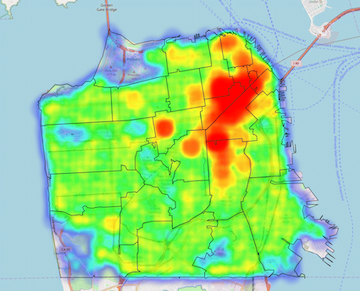

In [ ]:
corr = evcharge_data.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(16,5))
sns.heatmap(corr, cmap="Blues", annot=True);

Looking at the heatmap above, we can see that it represents the collinearity of the multiple variables in the dataset: <font color='blue'>dark blue</font> represents more positive correlations, while <font color='turquoise'>lighter blues</font> are more negative correlations. The key on the right demonstrates this!

**Can you name some variables that are correlated strongly with one another, and could you hypothesize why?**

*Your answer here*

In [ ]:
! pip install ydata-profiling
from ydata_profiling import ProfileReport

The above cell installs a feature that we need for the subsequent cell. It will likely produce a lot of code saying that it's downloaded or that certain things are 'already satisfied'. This is totally fine - we just wanted to install this so we can use it for the demonstration below.

Here, we use `profile_report()` ([documentation](https://pandas-profiling.ydata.ai/docs/master/index.html)) to produce summary statistics and a more user-friendly way of viewing the data. This is helpful particularly to present your information to those without experience or familiarity with other data-based explanations.

In [ ]:
plt.rcParams['figure.figsize'] = (16,10)
plt.rcParams['figure.dpi'] = 150
profile = ProfileReport(evcharge_data, title="EV Charging Data Profiling Report")
profile.to_notebook_iframe()

# Click "Pandas Profiling Report" to be able to more easily view the produced report.

<br>

## Station Popularity

Now, let's explore the data focusing on popularities of different stations in UCSD and UC Berkeley. We're comparing which stations use which sites.

Let's clean this data and just take the columns we're interested in, which are the `siteId` and`stationId` columns.

In [ ]:
essential_cols = evcharge_data[['siteId', 'stationId']]
essential_cols

**The unique ID's for stations:**
- UCSD: 3, 4, 5, 6, 7, 8, 9, 10
- UC Berkeley: 11, 12, 13, 14, 15, 16, 17 18

Now, let's **group by** the `stationId` columns in order to count how many sites are used in each station. We'll sort the values by `count` and display the top 5 most popular stations in UC Berkeley and UCSD.

In [ ]:
# Group by station IDs
group_by_station = essential_cols.groupby('stationId')['stationId'].count().reset_index(name="count").sort_values("count", ascending=False)
group_by_station.head(5) #shows only top 5

#### We can see that Stations 13, 12, 11, 15, and 16 are the 5 stations that use the most sites, out of both UCB and UCSD.

<br>

## 3. Analysis of EV Charging Stations in UC Berkeley <a id='2'></a>

**Now we will analyze which station is most popular at UC Berkeley.**

In [ ]:
ucb = [11, 12, 13, 14, 15, 16, 17, 18]
ucb_stations = group_by_station[group_by_station.stationId.isin(ucb)].sort_values('count', ascending = False)
ucb_stations

In [ ]:
plt.figure(figsize=(7,4))
plt.title("UC Berkeley's Station IDs vs Count of sites at station")
sns.barplot(x="stationId", y="count", data=ucb_stations);

**Which station number is the most popular in UC Berkeley?**

(Hint: Find the stationId with the highest count number)

*Your answer here*

## 4. Analysis of EV Charging Stations in UCSD <a id='3'></a>

Below, we repeat the same process but now to represent the data from UCSD.

In [ ]:
ucsd = [ 3, 4, 5, 6, 7, 8, 9, 10]
ucsd_stations = group_by_station[group_by_station.stationId.isin(ucsd)].sort_values('count', ascending = False)
ucsd_stations.head(5)

In [ ]:
plt.figure(figsize=(7,4))
plt.title("UC San Diego's Station IDs vs Count of sites at station")
sns.barplot(x="stationId", y="count", data=ucsd_stations);

**Which station number is the most popular in UCSD?**

(Hint: Find the stationId with the highest count number)

*Your answer here*

<br>

# 5. UCB vs. UCSD Energy Consumption <a id='4'></a>

Let's perform some data analysis now to **compare UC Berkeley and UCSD's energy consumption**.

First, let's group the `stationId` and `cumEnergy` columns to show how much cumulative energy each station uses, summing the total amount of energy.

In [ ]:
site_energy = evcharge_data[['stationId', 'cumEnergy']].groupby('stationId').agg(sum)
site_energy.head(5)

We can separate the `site_energy` table above to two different tables, the first one displayed being for UCB and the next for UCSD:

In [ ]:
ucb_energy = site_energy[site_energy.index.isin(ucb)]
ucsd_energy = site_energy[site_energy.index.isin(ucsd)]
display(ucb_energy)
display(ucsd_energy)

**Question:** Which UC Berkeley station uses the most cumulative energy?

*Insert answer here*

Let's find the cumulative energy usage of UC Berkeley using `sum`.

In [ ]:
ucb_cumEnergy = sum(ucb_energy['cumEnergy'])
ucb_cumEnergy

**Repeat the process to find the cumulative energy used by UCSD using `sum`.** Fill in the blank.

In [ ]:
ucsd_cumEnergy = sum(...['cumEnergy'])
ucsd_cumEnergy

In [ ]:
print("UC Berkeley Cumulative Energy Usage:", ucb_cumEnergy, ", UCSD Cumulative Energy Usage:", ucsd_cumEnergy)

#### Comparing the cumulative energy usage of UC Berkeley and UCSD, we can see that UC Berkeley uses much more energy than UCSD!

**Why do you think UC Berkeley uses more energy than UCSD? *(there are no wrong answers!)***

*Your answer here*

### Additional Analysis
We can also compare the number of unique users by grouping `stationId` with `userId`.

In [ ]:
users = evcharge_data[['stationId', 'userId']]
users.head(5)

Similarly, we can separate the `users` table to two different tables, one shown first for UCB and another below for UCSD:

In [ ]:
ucb_users = users[users['stationId'].isin(ucb)]
ucsd_users = users[users['stationId'].isin(ucsd)]
display(ucb_users.head(5))
display(ucsd_users.head(5))

We can also observe the **frequency that users charge**. Let's select the `userId` columns from the table of each school and *count* the number of values.

In [ ]:
# Observe the charging frequency of users.
ucb_users['userId'].value_counts().head(5)

In the above and below, the left column represents the User IDs and the right column represents the corresponding frequencies.

In [ ]:
ucsd_users['userId'].value_counts().head(5)

We can find the unique number of users in each school.

In [ ]:
# Find unique number of users in UCB
unique_ucb = len(ucb_users.groupby('userId'))
print('There are', unique_ucb, 'unique users of UC Berkeley charging stations represented in our data.')

In [ ]:
# Find unique number of users in UCSD
unique_ucsd = len(ucsd_users.groupby('userId'))
print('There are', unique_ucsd, 'unique users of UC San Diego charging stations represented in our data.')

**Finally, let's take a look at the total charges for each school, which can be calculated by dividing the total cumulative energy by the total number of users!**

In [ ]:
# Find total number of users per school
tot_ucb_users = len(ucb_users)
tot_ucsd_users = len(ucsd_users)

In [ ]:
# Feel free to use this cell to assist your calculation for the fill-in-the-blank question below

**The total users at UCB are _____ the total users at UCSD.**

#### Fill in the blank above with less than, greater than, or equal to.

In [ ]:
# Find UCB total charge
ucb_totalCharge = ucb_cumEnergy / tot_ucb_users
ucb_totalCharge

In [ ]:
# Find UCSD total charge
ucsd_totalCharge = ucsd_cumEnergy / tot_ucsd_users
ucsd_totalCharge

In [ ]:
print("UC Berkeley Total Charge:", ucb_totalCharge, ", UCSD Cumulative Total Charge:", ucsd_totalCharge)

From this, we can see that although UC Berkeley uses more overall cumulative energy, the total charge is actually ***less*** than UCSD.

<br>

## 6. Conclusion <a id='5'></a>

Great job for finishing the notebook! 
A quick recap of what you learned in this notebook: 
* Grouped together and found attributes belonging to UC Berkeley and UCSD
* Created graphs to find most common values in dataset

<br>

## 7. Explore Data Science Opportunities  <a id='6'></a>

Interested in learning more about how to get involved in data science or learn about data science applications in your field of study? The following resources might help support your learning:

---

- Data Science Modules: https://cdss.berkeley.edu/dsus/modules

- Data Science Offerings at Berkeley: https://cdss.berkeley.edu/dsus/academics/courses

- Data 8 Course Information: http://data8.org/

- Data 100 Course Information: https://ds100.org/


## 8. Feedback Form <a id='7'></a>

<div class="alert alert-info">
<b> We encourage student to fill out the following feedback form to share your experience with this Module notebook. This feedback form will take no longer than 5 minutes. At UC Berkeley Data Science Undergraduate Studies Modules, we appreciate all feedback to improve the learning of students and experience utilizing Jupyter Notebooks for Data Science Education: </b> 
</div>

### [UC Berkeley Data Science Feedback Form](https://forms.gle/hipxf2uFw5Ud4Hyn8)

<br>

This notebook was created by Skye Pickett, Lori Khashaki, Vishali Kirthi, and Abigail Yu - modified by Edwin Vargas Navarro.